# FIFA World Cup 2026 – Analytic Task 4 Only

## Analytic question
**Do knockout-stage teams have a different average goalkeeper save percentage from group-stage exit teams?**

**H0:** Mean save percentage is equal between knockout-stage and group-stage exit teams.  
**H1:** The two population means differ.

This notebook contains only **Task 4**.

## 1. Import libraries and helper functions

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

RANDOM_STATE = 42
ALPHA = 0.05

def make_unique(columns):
    counts = {}
    out = []
    for col in columns:
        col = str(col).replace("▼", "").strip()
        if col in counts:
            counts[col] += 1
            out.append(f"{col}.{counts[col]}")
        else:
            counts[col] = 0
            out.append(col)
    return out

def read_fbref_csv(path):
    df = pd.read_csv(path, header=1)
    df.columns = make_unique(df.columns)
    df = df.loc[:, ~df.columns.astype(str).str.match("^Unnamed")]
    for c in df.columns:
        if c not in ["Player", "Pos", "Squad", "Club", "Matches"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(how="all").reset_index(drop=True)

def ci_mean(x, confidence=0.95):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    tcrit = stats.t.ppf((1 + confidence) / 2, n - 1)
    return pd.Series({
        "n": n, "mean": mean, "sd": sd, "se": se,
        "lower": mean - tcrit*se,
        "upper": mean + tcrit*se
    })

def welch_ci_diff(x1, x2, confidence=0.95):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)
    n1, n2 = len(x1), len(x2)
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    df = (v1/n1 + v2/n2)**2 / (((v1/n1)**2)/(n1-1) + ((v2/n2)**2)/(n2-1))
    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    diff = m1 - m2
    return pd.Series({
        "difference": diff,
        "lower": diff - tcrit*se,
        "upper": diff + tcrit*se,
        "df": df
    })

def descriptive_table(sample, group_col, value_col):
    return sample.groupby(group_col)[value_col].agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        max="max"
    ).round(3)

def assumption_checks(g1, g2, label1, label2):
    sh1 = stats.shapiro(g1)
    sh2 = stats.shapiro(g2)
    lev = stats.levene(g1, g2)

    def outlier_count(x):
        q1, q3 = x.quantile([0.25, 0.75])
        iqr = q3 - q1
        return int(((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum())

    return pd.Series({
        f"Shapiro p ({label1})": sh1.pvalue,
        f"Shapiro p ({label2})": sh2.pvalue,
        "Levene p": lev.pvalue,
        f"IQR outliers ({label1})": outlier_count(g1),
        f"IQR outliers ({label2})": outlier_count(g2)
    })

def stratified_sample(df, group_col, n_per_group):
    return pd.concat([
        sub.sample(n=min(n_per_group, len(sub)), random_state=RANDOM_STATE)
        for _, sub in df.groupby(group_col, sort=False)
    ], ignore_index=True)

print("Setup complete.")

Setup complete.


## 2. Load and validate squad goalkeeping data

In [2]:
squad_standard = read_fbref_csv("squad_standard.csv")
squad_goalkeeping = read_fbref_csv("squad_goalkeeping.csv")

print("squad_standard:", squad_standard.shape)
print("squad_goalkeeping:", squad_goalkeeping.shape)
print("Same number of squads:", len(squad_standard) == len(squad_goalkeeping))
print("Save% within 0–100:", bool(squad_goalkeeping["Save%"].dropna().between(0, 100).all()))
print("Saves <= SoTA:", bool((squad_goalkeeping["Saves"] <= squad_goalkeeping["SoTA"]).all()))

display(squad_goalkeeping.head())

squad_standard: (48, 21)
squad_goalkeeping: (48, 21)
Same number of squads: True
Save% within 0–100: True
Saves <= SoTA: True


,Squad,# Pl,MP,Starts,Min,90s,GA,GA90,SoTA,Saves,Save%,W,D,L,CS,CS%,PKatt,PKA,PKsv,PKm,Save%.1
0,es Spain,1,8,8,750,8.3,1,0.12,11,9,90.9,7,1,0,7,87.5,0,0,0,0,NaN
1,pt Portugal,1,5,5,450,5.0,3,0.60,22,19,86.4,2,2,1,2,40.0,0,0,0,0,NaN
2,co Colombia,1,5,5,480,5.3,1,0.19,7,6,85.7,3,1,1,4,80.0,0,0,0,0,NaN
3,gh Ghana,2,4,4,360,4.0,3,0.75,19,16,84.2,1,1,2,2,50.0,0,0,0,0,NaN
4,ir IR Iran,1,3,3,270,3.0,3,1.00,18,15,83.3,0,3,0,1,33.3,0,0,0,0,NaN


## 3. Data wrangling and workload variable

Goalkeeping statistics are merged with squad standard data.

Progression is derived from matches played:
- `MP = 3` → group-stage exit
- `MP > 3` → reached knockout stage

We also create:

\[
	ext{Shots on target against per 90} = rac{	ext{SoTA}}{	ext{90s}}
\]

This provides useful workload context for interpreting save percentage.

In [3]:
team_gk = squad_goalkeeping[
    ["Squad", "MP", "90s", "GA", "GA90", "SoTA", "Saves", "Save%", "CS%"]
].merge(
    squad_standard[["Squad", "MP"]],
    on="Squad",
    suffixes=("", "_std"),
    validate="one_to_one"
)

team_gk["Progression"] = np.where(
    team_gk["MP_std"] > 3,
    "Knockout stage",
    "Group-stage exit"
)

team_gk["SoTA_per90"] = team_gk["SoTA"] / team_gk["90s"]

display(team_gk.head())
print("\nPopulation counts:")
display(team_gk["Progression"].value_counts())

,Squad,MP,90s,GA,GA90,SoTA,Saves,Save%,CS%,MP_std,Progression,SoTA_per90
0,es Spain,8,8.3,1,0.12,11,9,90.9,87.5,8,Knockout stage,1.325301
1,pt Portugal,5,5.0,3,0.60,22,19,86.4,40.0,5,Knockout stage,4.400000
2,co Colombia,5,5.3,1,0.19,7,6,85.7,80.0,5,Knockout stage,1.320755
3,gh Ghana,4,4.0,3,0.75,19,16,84.2,50.0,4,Knockout stage,4.750000
4,ir IR Iran,3,3.0,3,1.00,18,15,83.3,33.3,3,Group-stage exit,6.000000



Population counts:


Progression
Knockout stage      32
Group-stage exit    16
Name: count, dtype: int64

## 4. Population, sampling frame and sampling

**Population:** all FIFA World Cup 2026 squads.  
**Sampling frame:** squads with valid goalkeeping statistics.  
**Sampling method:** stratified random sampling by progression with `random_state=42`.

All 16 group-stage exits are retained and 16 knockout-stage teams are randomly sampled.

In [4]:
task4_eligible = team_gk[
    team_gk["Save%"].notna() &
    np.isfinite(team_gk["SoTA_per90"])
].copy()

task4_sample = stratified_sample(task4_eligible, "Progression", 16)

print("Sample counts:")
display(task4_sample["Progression"].value_counts())

task4_sample.to_csv("task4_sample.csv", index=False)

Sample counts:


Progression
Knockout stage      16
Group-stage exit    16
Name: count, dtype: int64

## 5. Descriptive statistics

In [5]:
descriptive = descriptive_table(task4_sample, "Progression", "Save%")
display(descriptive)

,count,mean,median,std,min,q1,q3,max
Progression,,,,,,,,
Group-stage exit,16,58.531,58.95,13.907,33.3,50.000,67.275,83.3
Knockout stage,16,68.950,70.70,11.887,47.1,58.675,76.375,90.9


## 6. 95% confidence intervals

In [6]:
ko = task4_sample.loc[
    task4_sample["Progression"] == "Knockout stage", "Save%"
].dropna().astype(float)

ex = task4_sample.loc[
    task4_sample["Progression"] == "Group-stage exit", "Save%"
].dropna().astype(float)

print("95% CI – Knockout stage")
display(ci_mean(ko).round(3))

print("95% CI – Group-stage exit")
display(ci_mean(ex).round(3))

print("95% CI – mean difference (Knockout - Exit)")
display(welch_ci_diff(ko, ex).round(3))

95% CI – Knockout stage


n        16.000
mean     68.950
sd       11.887
se        2.972
lower    62.616
upper    75.284
dtype: float64

95% CI – Group-stage exit


n        16.000
mean     58.531
sd       13.907
se        3.477
lower    51.121
upper    65.942
dtype: float64

95% CI – mean difference (Knockout - Exit)


difference    10.419
lower          1.068
upper         19.769
df            29.290
dtype: float64

## 7. Welch two-sample t-test

In [7]:
t_stat, p_value = stats.ttest_ind(ko, ex, equal_var=False)

print("t statistic =", round(t_stat, 5))
print("p-value =", round(p_value, 5))

if p_value < ALPHA:
    print("Decision: Reject H0 at alpha = 0.05.")
else:
    print("Decision: Fail to reject H0 at alpha = 0.05.")

t statistic = 2.27792
p-value = 0.03021
Decision: Reject H0 at alpha = 0.05.


## 8. Assumption checks and sensitivity analysis

In [8]:
display(assumption_checks(ko, ex, "Knockout", "Exit").round(5))

u_stat, u_p = stats.mannwhitneyu(ko, ex, alternative="two-sided")
print("\nMann-Whitney U sensitivity check")
print("U statistic:", round(u_stat, 5))
print("p-value:", round(u_p, 5))

Shapiro p (Knockout)       0.69528
Shapiro p (Exit)           0.95070
Levene p                   0.49499
IQR outliers (Knockout)    0.00000
IQR outliers (Exit)        0.00000
dtype: float64


Mann-Whitney U sensitivity check
U statistic: 182.5
p-value: 0.04174


## 9. Visualisation

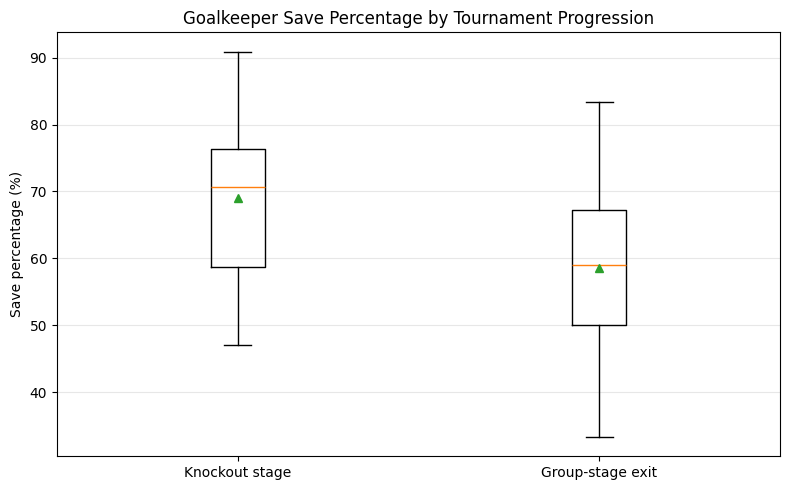

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
vals = [
    task4_sample.loc[task4_sample["Progression"] == "Knockout stage", "Save%"],
    task4_sample.loc[task4_sample["Progression"] == "Group-stage exit", "Save%"]
]
ax.boxplot(vals, tick_labels=["Knockout stage", "Group-stage exit"], showmeans=True)
ax.set_title("Goalkeeper Save Percentage by Tournament Progression")
ax.set_ylabel("Save percentage (%)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("task4_boxplot.png", dpi=200)
plt.show()

## 10. Interpretation and limitation

Report the group means, 95% confidence interval for the difference, Welch t-test p-value and decision.

**Football interpretation:** save percentage standardises shot-stopping outcomes better than simply comparing raw save totals.

**Limitation:** team save percentage is influenced by goalkeeper quality and the defensive system, shot quality and opposition strength.